# Implement FC model using HLS4ML
Starting from a downloaded dataset, generates Float model and QAT of 16, 8 and 4-bit models

Loads pre-generated MFCC dataset splits from `MFCC_datasets/` and trains a CNN classifier for speaker recognition.

**Prerequisites:** Run `MFCC_dataset_generation.ipynb` first (including the *Dataset Export* cell) to produce:
- `MFCC_datasets/train_batches/`
- `MFCC_datasets/validation_batches/`
- `MFCC_datasets/test_batches/`
- `MFCC_datasets/element_spec.pkl`
- `MFCC_datasets/metadata.json`

In [1]:
import os, json, re, warnings
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt

import librosa
import librosa.display
import numpy as np
import pandas as pd
import seaborn as sns


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    InputLayer, BatchNormalization
)
from tensorflow.keras.optimizers import Adam

os.environ['XILINX_VITIS'] = '/tools/Xilinx/Vitis/2024.1'
os.environ['XILINX_HLS'] = '/tools/Xilinx/Vitis_HLS/2024.1'
os.environ['PATH'] += ':/tools/Xilinx/Vitis_HLS/2024.1/bin'
os.environ['PATH'] = os.environ['XILINX_VITIS'] + '/bin:' + os.environ['PATH']


# QKeras – quantization-aware training
from qkeras import QConv2D, QDense, QActivation, quantized_bits, quantized_relu
from qkeras.utils import _add_supported_quantized_objects

from tensorflow.keras.models import Sequential
from tensorflow.keras.models import load_model

from tensorflow.keras.layers import (InputLayer, 
                                     BatchNormalization,
                                     MaxPooling2D,
                                     Flatten,
                                     Dropout                                
)
from tensorflow.keras.optimizers import Adam

co = {}
_add_supported_quantized_objects(co)
Model_Float = load_model('CNN_Model_Trained/Trained_model_100e.h5', custom_objects=co)
# hls4ml – HLS model conversion and synthesis
import hls4ml

## Random Seed for Reproducibility
RANDOM_SEED = 55
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)
warnings.filterwarnings('ignore')


# ── FPGA target (Kria KV260-compatible) ───────────────────────────────────
FPGA_PART    = 'xck26-sfvc784-2LV-c'
CLOCK_PERIOD = 5   # ns → 200 MHz
TARGET_SNR   = '76dB'

# ── hls4ml output ─────────────────────────────────────────────────────────
HLS_BASE_DIR = './hls4ml_output'

# ── Training hyper-parameters ─────────────────────────────────────────────
BATCH_SIZE    = 32
MAX_EPOCHS    = 100
LEARNING_RATE = 1e-4
PATIENCE      = 20



2026-04-14 19:09:42.466513: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


# Load dataset parameters for model generation

In [2]:
# ── Datasets parameters ─────────────────────────────────────────────
DATASETS_PATH = "MFCC_datasets"
METADATA_PATH = os.path.join(DATASETS_PATH, "metadata.json")

if os.path.exists(METADATA_PATH):
    with open(METADATA_PATH, "r") as f:
        metadata = json.load(f)
    MFCC_input_shape = tuple(metadata["MFCC_input_shape"])
    NUM_CLASSES      = metadata["num_classes"]
    N_MFCC           = metadata.get("N_MFCC", 20)
    MFCC_FRAMES      = metadata.get("MFCC_FRAMES")
    SAMPLING_FREQ    = metadata.get("SAMPLING_FREQ", 48000)
    batch_size       = metadata.get("batch_size", 32)
    subfolders       = metadata.get("subfolders", [])
    unique_labels    = metadata.get("labels", [])
    print("Metadata loaded from metadata.json")
else:
    # Fallback: infer parameters from the dataset after loading
    print("Warning: metadata.json not found. Parameters will be inferred from the dataset.")
    N_MFCC        = 20
    SAMPLING_FREQ = 48000
    batch_size    = 32
    subfolders    = []
    MFCC_input_shape = None
    NUM_CLASSES      = None

print(f"  MFCC input shape : {MFCC_input_shape}")
print(f"  Num classes      : {NUM_CLASSES}")
print(f"  N_MFCC           : {N_MFCC}")
print(f"  MFCC_FRAMES      : {MFCC_FRAMES}")
print(f"  Sampling freq    : {SAMPLING_FREQ} Hz")
print(f"  Batch size       : {batch_size}")
print(f"  Classes          : {subfolders}")


Metadata loaded from metadata.json
  MFCC input shape : (20, 64, 2)
  Num classes      : 10
  N_MFCC           : 20
  MFCC_FRAMES      : 64
  Sampling freq    : 48000 Hz
  Batch size       : 32
  Classes          : ['f0001', 'f0002', 'f0003', 'f0004', 'f0005', 'm0001', 'm0002', 'm0003', 'm0004', 'm0005']


# Load elements for MFCC dataset generation

In [3]:
# Load element specs saved by MFCC_dataset_generation.ipynb
SPEC_PATH = os.path.join(DATASETS_PATH, "element_spec.pkl")
with open(SPEC_PATH, "rb") as f:
    specs = pickle.load(f)

MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "train_batches"),
    element_spec=specs["train"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "validation_batches"),
    element_spec=specs["validation"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_test_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "test_batches"),
    element_spec=specs["test"]
).prefetch(tf.data.AUTOTUNE)

print(f"Train batches      : {MFCC_dataset_train_batches.cardinality().numpy()}")
print(f"Validation batches : {MFCC_dataset_validation_batches.cardinality().numpy()}")
print(f"Test batches       : {MFCC_dataset_test_batches.cardinality().numpy()}")

# Verify shapes and infer missing parameters when metadata.json is absent
for data_batch, label_batch in MFCC_dataset_train_batches.take(1):
    print(f"\nData batch shape   : {data_batch.shape}")
    print(f"Labels batch shape : {label_batch.shape}")
    if MFCC_input_shape is None:
        MFCC_input_shape = tuple(data_batch.shape[1:])
        print(f"Inferred MFCC_input_shape: {MFCC_input_shape}")
    else:        
        print(f"Read MFCC_input_shape: {MFCC_input_shape}")

Train batches      : 72
Validation batches : 16
Test batches       : 16

Data batch shape   : (32, 20, 64, 2)
Labels batch shape : (32,)
Read MFCC_input_shape: (20, 64, 2)


# Define Model (float 32)

In [4]:
Model_Float = Sequential([
    # input_shape seems to be depracated. Consider is 'shape' is causing problems
    InputLayer(input_shape=MFCC_input_shape),

    Flatten(),# Flattens to 2560 features

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),


    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),

    Dense(NUM_CLASSES, activation='softmax')
])

Model_Float.summary()

loss_function  = 'sparse_categorical_crossentropy'
metrics        = ['accuracy']

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)
Model_Float.compile(
    optimizer=optimizer,
    loss=loss_function,
    metrics=metrics
)

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 flatten (Flatten)           (None, 2560)              0         
                                                                 
 dense (Dense)               (None, 256)               655616    
                                                                 
 batch_normalization (Batch  (None, 256)               1024      
 Normalization)                                                  
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 64)                16448     
                                                                 
 batch_normalization_1 (Bat  (None, 64)                256       
 chNormalization)                                       

# Float model training

In [5]:
class EpochModelSaver(tf.keras.callbacks.Callback):
    def __init__(self, model, path, every_n_epochs=5, prefix="ckpt"):
        super().__init__()
        os.makedirs(path, exist_ok=True)
        self.path          = path
        self.save_freq     = every_n_epochs
        self.prefix        = prefix
        self.model_to_save = model

    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.save_freq == 0:
            save_path = os.path.join(self.path, f"{self.prefix}_epoch_{epoch + 1:03d}.h5")
            self.model_to_save.save(save_path)
            print(f"\nModelo guardado en: {save_path}")


early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=PATIENCE,
    restore_best_weights=True
)


def save_history(history, filename):
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            print(f"Appending to existing history file: {filename}")
            old_history = json.load(f)
            for key in history.history:
                old_history[key].extend(history.history[key])
    else:
        old_history = history.history

    with open(filename, 'w') as f:
        json.dump(old_history, f)


def load_history(filename):
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            print(f"Loading history from file: {filename}")
            return json.load(f)
    return {}

In [6]:
history_MFCC = Model_Float.fit(
    MFCC_dataset_train_batches,
    epochs=100,
    validation_data=MFCC_dataset_validation_batches,
    callbacks=[early_stopping_callback]
)

# Save training history to CSV
pd.DataFrame.from_dict(history_MFCC.history).to_csv('MFCC_training_FC_history.csv', index=False)

#Save trained model
Model_Float.save('CNN_Model_Trained/Trained_FC_float_model_100e.h5')

Epoch 1/100
72/72 [==============================] - 1s 6ms/step - loss: 2.5091 - accuracy: 0.2245 - val_loss: 1.6938 - val_accuracy: 0.4146
Epoch 2/100
72/72 [==============================] - 0s 4ms/step - loss: 1.7614 - accuracy: 0.3973 - val_loss: 1.2556 - val_accuracy: 0.5955
Epoch 3/100
72/72 [==============================] - 0s 4ms/step - loss: 1.3688 - accuracy: 0.5213 - val_loss: 0.9930 - val_accuracy: 0.7114
Epoch 4/100
72/72 [==============================] - 0s 4ms/step - loss: 1.1288 - accuracy: 0.6188 - val_loss: 0.8184 - val_accuracy: 0.7724
Epoch 5/100
72/72 [==============================] - 0s 4ms/step - loss: 0.9336 - accuracy: 0.7010 - val_loss: 0.6936 - val_accuracy: 0.8110
Epoch 6/100
72/72 [==============================] - 0s 4ms/step - loss: 0.7847 - accuracy: 0.7676 - val_loss: 0.6032 - val_accuracy: 0.8557
Epoch 7/100
72/72 [==============================] - 0s 4ms/step - loss: 0.6688 - accuracy: 0.8107 - val_loss: 0.5408 - val_accuracy: 0.8760
Epoch 8/100
7

# Evaluate trained model

Max value for loss: 2.509084463119507
Max value for accuracy: 1.0
Max value for val_loss: 1.693779706954956
Max value for val_accuracy: 0.9695122241973877


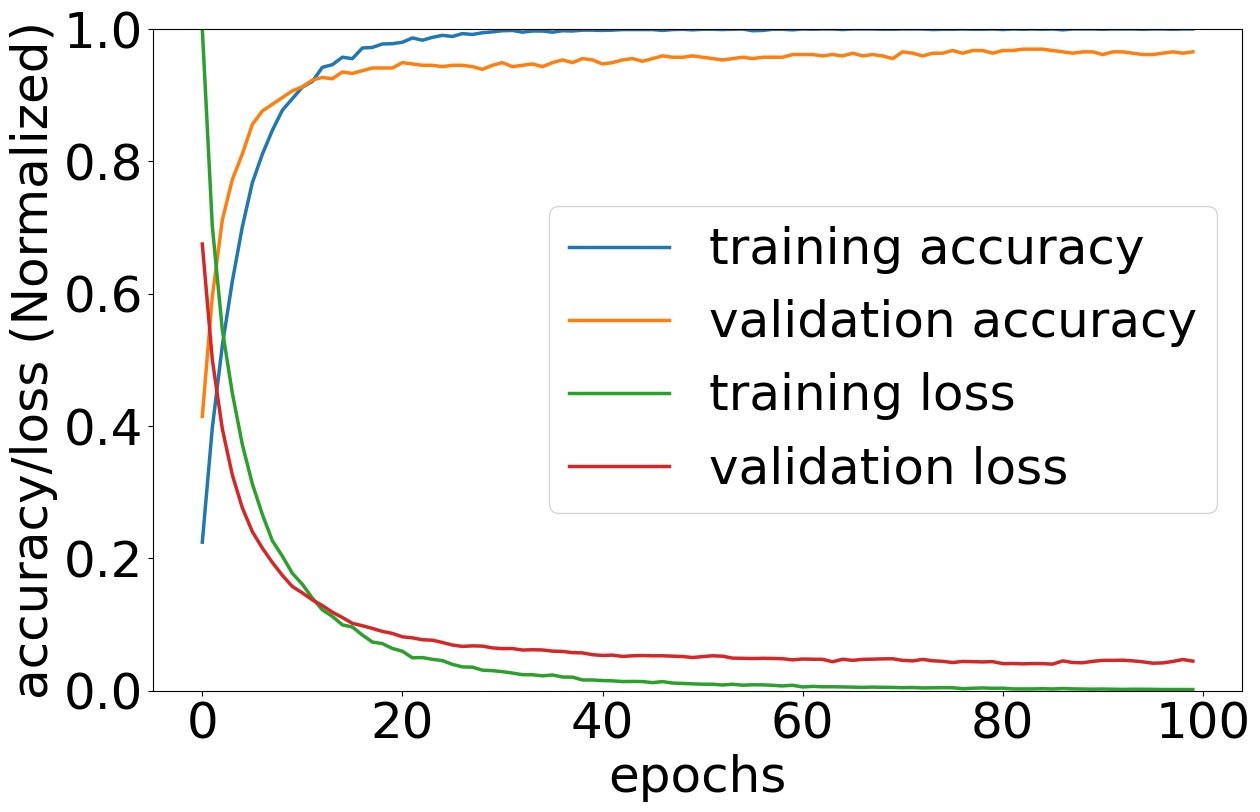

In [7]:
# Save training history to JSON (overwrites any previous run)
history_path = "training_history_FC.json"
with open(history_path, 'w') as f:
    json.dump(history_MFCC.history, f)


def plot_confusion_matrix(cm, labels):
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicción')
    plt.ylabel('Realidad')
    plt.title('Matriz de Confusión')
    plt.show()


plt.rcParams.update({'font.size': 36})
plt.rcParams['lines.linewidth'] = 2.5


def new_cnn_plot_training_history_classification(history, metrics):
    fig_size         = 9
    fig_aspect_ratio = 3 / 2

    plt.figure(figsize=(fig_aspect_ratio * fig_size, fig_size))
    for i, metric in enumerate(metrics):
        if metric == 'loss':
            normalized_hist = {}
            total_max_val   = 0
            for key, values in history.items():
                max_val       = max(values)
                print(f"Max value for {key}: {max_val}")
                total_max_val = max(max_val, total_max_val)
                normalized_hist[key] = [val / total_max_val for val in values]
            history = normalized_hist
        plt.plot(history[f'{metric}'],     label=f'training {metric}')
        plt.plot(history[f'val_{metric}'], label=f'validation {metric}')
        plt.xlabel('epochs')
        plt.ylabel('accuracy/loss (Normalized)')
        plt.ylim([0, 1])
        plt.legend()

    plt.tight_layout()
    plt.show()


# Plot the most recent training run only
new_cnn_plot_training_history_classification(history_MFCC.history, metrics=['accuracy', 'loss'])

# Quantization-Aware Training (QAT)

Three QKeras models are fine-tuned starting from the float weights:

| Model | Weight / activation precision |
|---|---|
| QAT 16-bit | `quantized_bits(16, 6)` |
| QAT 8-bit  | `quantized_bits(8, 4)`  |
| QAT 4-bit  | `quantized_bits(4, 2)`  |

Fine-tuning starts from the float checkpoint; fewer epochs and a lower
learning rate let the network adapt to reduced precision without
catastrophic forgetting.

In [8]:

def build_qat_model(input_shape, n_classes, bits, integer_bits):

    #Quantizers
    kq = quantized_bits(bits, integer_bits, keep_negative=1, alpha=1)
    aq = quantized_relu(bits, integer_bits)

    q_Model = Sequential([
        InputLayer(input_shape),

        #Classifier
        Flatten(name='flatten'),

        #Block 1
        QDense(256, kernel_quantizer=kq, bias_quantizer=kq, name='dense1'),
        BatchNormalization(name='bn1'),
        Dropout(0.3, name='dropout1'),

        #Block 2
        QDense(64, kernel_quantizer=kq, bias_quantizer=kq, name='dense2'),
        BatchNormalization(name='bn2'),
        Dropout(0.3, name='dropout2'),

        QDense(n_classes, kernel_quantizer=kq, bias_quantizer=kq, name='output'),
        
        #Softmax remains in float for stability.
        tf.keras.layers.Activation('softmax', name='softmax'),
    ], name=f'MFCC_CNN_QAT_{bits}bit')

    return q_Model


def transfer_float_weights(float_model, qat_model):
    float_wl = [l for l in float_model.layers if l.get_weights()]
    qat_wl   = [l for l in qat_model.layers  if l.get_weights()]
    n_ok = 0
    for fl, ql in zip(float_wl, qat_wl):
        try:
            ql.set_weights(fl.get_weights())
            n_ok += 1
        except ValueError:
            print(f'  Skipped: {fl.name} -> {ql.name} (shape mismatch)')
    print(f'  Transferred weights for {n_ok} layer(s).')


# Custom-objects dict needed when reloading QKeras models
QKERAS_CUSTOM_OBJECTS = {}
_add_supported_quantized_objects(QKERAS_CUSTOM_OBJECTS)

#Import Training parameters needed for QAT

# ── Load Training parameters ─────────────────────────────────────────────
SPEC_PATH = os.path.join(DATASETS_PATH, "element_spec.pkl")
with open(SPEC_PATH, "rb") as f:
    specs = pickle.load(f)
    
MFCC_dataset_train_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "train_batches"),
    element_spec=specs["train"]
).prefetch(tf.data.AUTOTUNE)

MFCC_dataset_validation_batches = tf.data.Dataset.load(
    os.path.join(DATASETS_PATH, "validation_batches"),
    element_spec=specs["validation"]
).prefetch(tf.data.AUTOTUNE)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)
# ───────────────────────────────────────────────
MFCC_input_shape =  Model_Float.input_shape[1:]

print(f"Read MFCC_input_shape: {MFCC_input_shape}")


# Compare configurations


In [9]:
# These functions should be recognized from other notebooks pero aja

# ── History helpers ──────────────────────────────────────────────────────

def save_history(history_obj, filepath):
    # Saves a Keras History to JSON; appends to existing file if present.
    new_hist = {k: list(map(float, v)) for k, v in history_obj.history.items()}
    if os.path.exists(filepath):
        with open(filepath) as f:
            old_hist = json.load(f)
        for key, vals in new_hist.items():
            old_hist.setdefault(key, []).extend(vals)
        combined = old_hist
    else:
        combined = new_hist
    with open(filepath, 'w') as f:
        json.dump(combined, f, indent=2)
    print(f'History saved -> {filepath}')

def load_history(filepath):
    with open(filepath) as f:
        return json.load(f)


def plot_training_history(history_dict, title='Training History'):
    # FIX #8: independent per-curve normalization for the loss plot.
    # The original code used a running total_max_val that mutated while
    # iterating over keys, mixing the denominators of loss and val_loss.
    fig, axes = plt.subplots(1, 2, figsize=(24, 15))

    axes[0].plot(history_dict.get('accuracy',     []), label='Train')
    axes[0].plot(history_dict.get('val_accuracy', []), label='Validation')
    axes[0].set(xlabel='Epoch', ylabel='Accuracy', ylim=[0, 1], title='Accuracy')
    axes[0].legend()

    for key in ['loss', 'val_loss']:
        vals = history_dict.get(key, [])
        if not vals:
            continue
        mx = max(vals) or 1.0
        axes[1].plot([v / mx for v in vals], label=key)
    axes[1].set(xlabel='Epoch', ylabel='Normalized loss',
                title='Loss (each curve normalized to its own max)', ylim=[0, 1])
    axes[1].legend()

    plt.suptitle(title)
    plt.tight_layout()   # FIX #9: added ()
    plt.show()


  QAT 16-bit  (integer_bits=6)
Building QAT model and transferring float weights ...
  Transferred weights for 5 layer(s).
Epoch 1/100
72/72 [==============================] - 1s 8ms/step - loss: 0.0897 - accuracy: 0.9756 - val_loss: 0.1607 - val_accuracy: 0.9573
Epoch 2/100
72/72 [==============================] - 0s 5ms/step - loss: 0.0819 - accuracy: 0.9791 - val_loss: 0.1266 - val_accuracy: 0.9675
Epoch 3/100
72/72 [==============================] - 0s 5ms/step - loss: 0.0777 - accuracy: 0.9791 - val_loss: 0.1220 - val_accuracy: 0.9634
Epoch 4/100
72/72 [==============================] - 0s 6ms/step - loss: 0.0761 - accuracy: 0.9839 - val_loss: 0.1196 - val_accuracy: 0.9614
Epoch 5/100
72/72 [==============================] - 0s 6ms/step - loss: 0.0707 - accuracy: 0.9826 - val_loss: 0.1163 - val_accuracy: 0.9654
Epoch 6/100
72/72 [==============================] - 0s 6ms/step - loss: 0.0669 - accuracy: 0.9835 - val_loss: 0.1146 - val_accuracy: 0.9654
Epoch 7/100
72/72 [===========

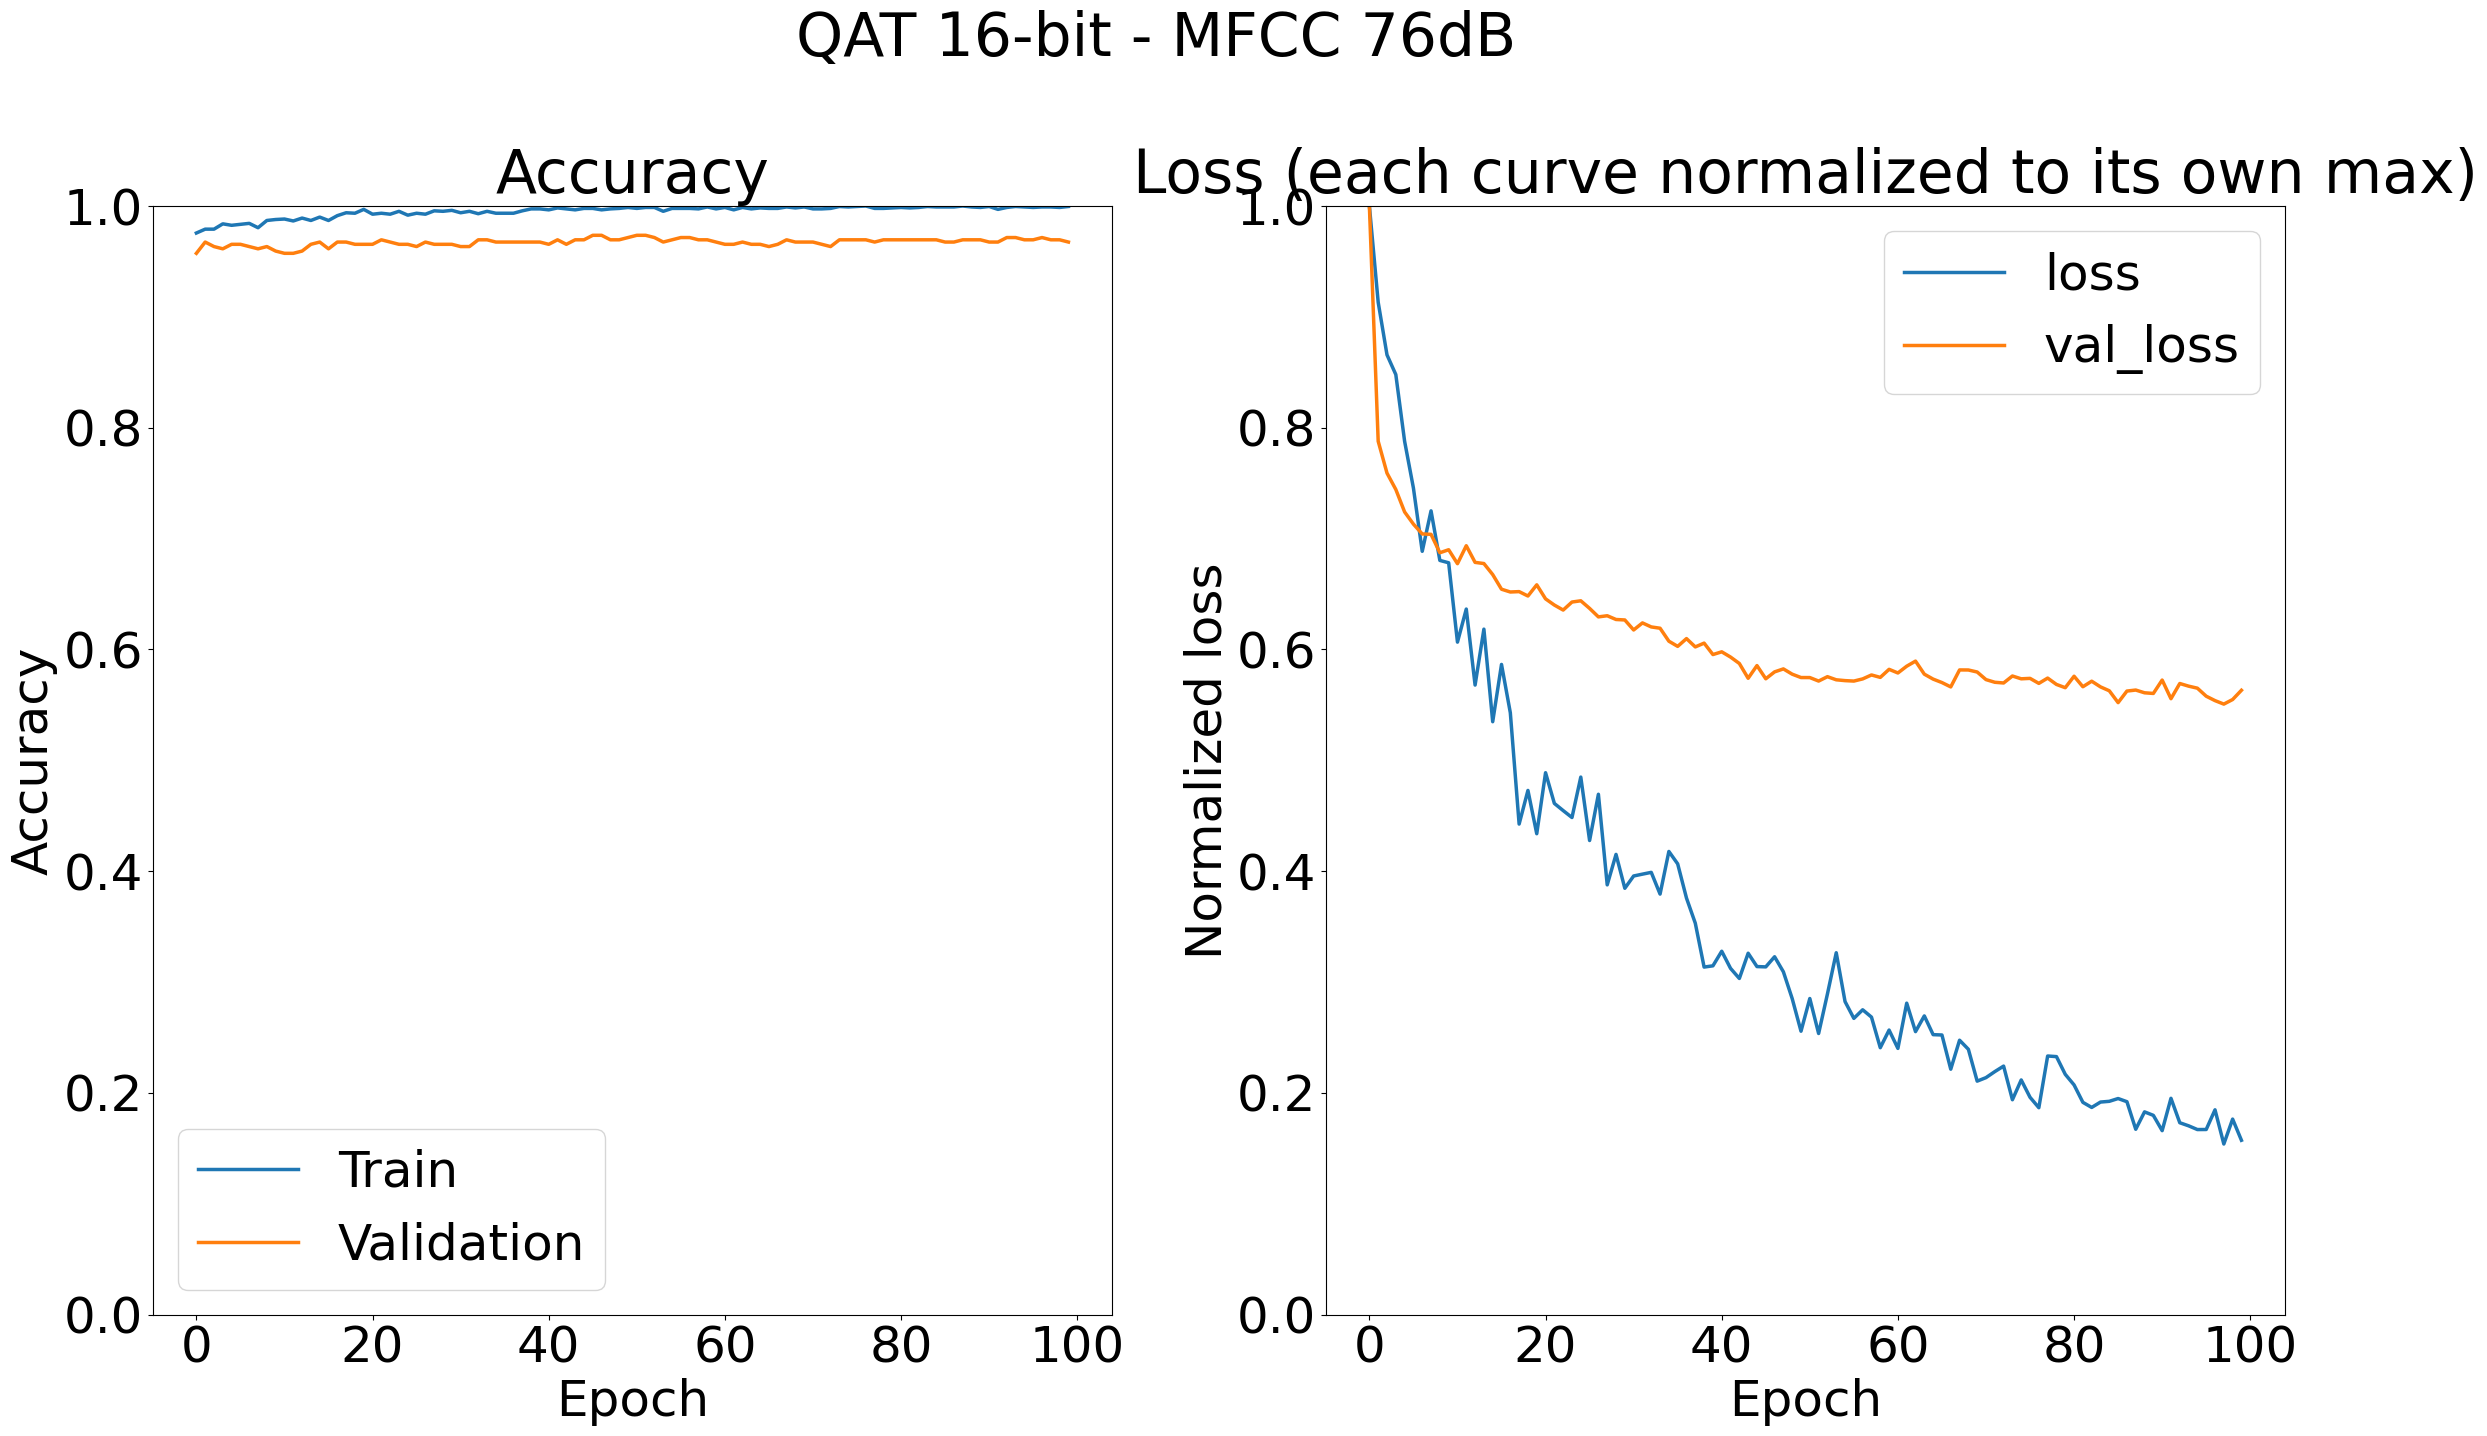


  QAT 8-bit  (integer_bits=4)
Building QAT model and transferring float weights ...
  Transferred weights for 5 layer(s).
Epoch 1/100
72/72 [==============================] - 1s 8ms/step - loss: 0.8650 - accuracy: 0.7324 - val_loss: 0.9975 - val_accuracy: 0.6484
Epoch 2/100
72/72 [==============================] - 0s 5ms/step - loss: 0.8880 - accuracy: 0.7306 - val_loss: 0.6588 - val_accuracy: 0.8049
Epoch 3/100
72/72 [==============================] - 0s 5ms/step - loss: 0.8040 - accuracy: 0.7511 - val_loss: 0.5082 - val_accuracy: 0.8394
Epoch 4/100
72/72 [==============================] - 0s 5ms/step - loss: 0.7749 - accuracy: 0.7572 - val_loss: 0.4501 - val_accuracy: 0.8618
Epoch 5/100
72/72 [==============================] - 0s 6ms/step - loss: 0.7511 - accuracy: 0.7663 - val_loss: 0.4138 - val_accuracy: 0.8720
Epoch 6/100
72/72 [==============================] - 0s 5ms/step - loss: 0.7007 - accuracy: 0.7737 - val_loss: 0.4002 - val_accuracy: 0.8720
Epoch 7/100
72/72 [============

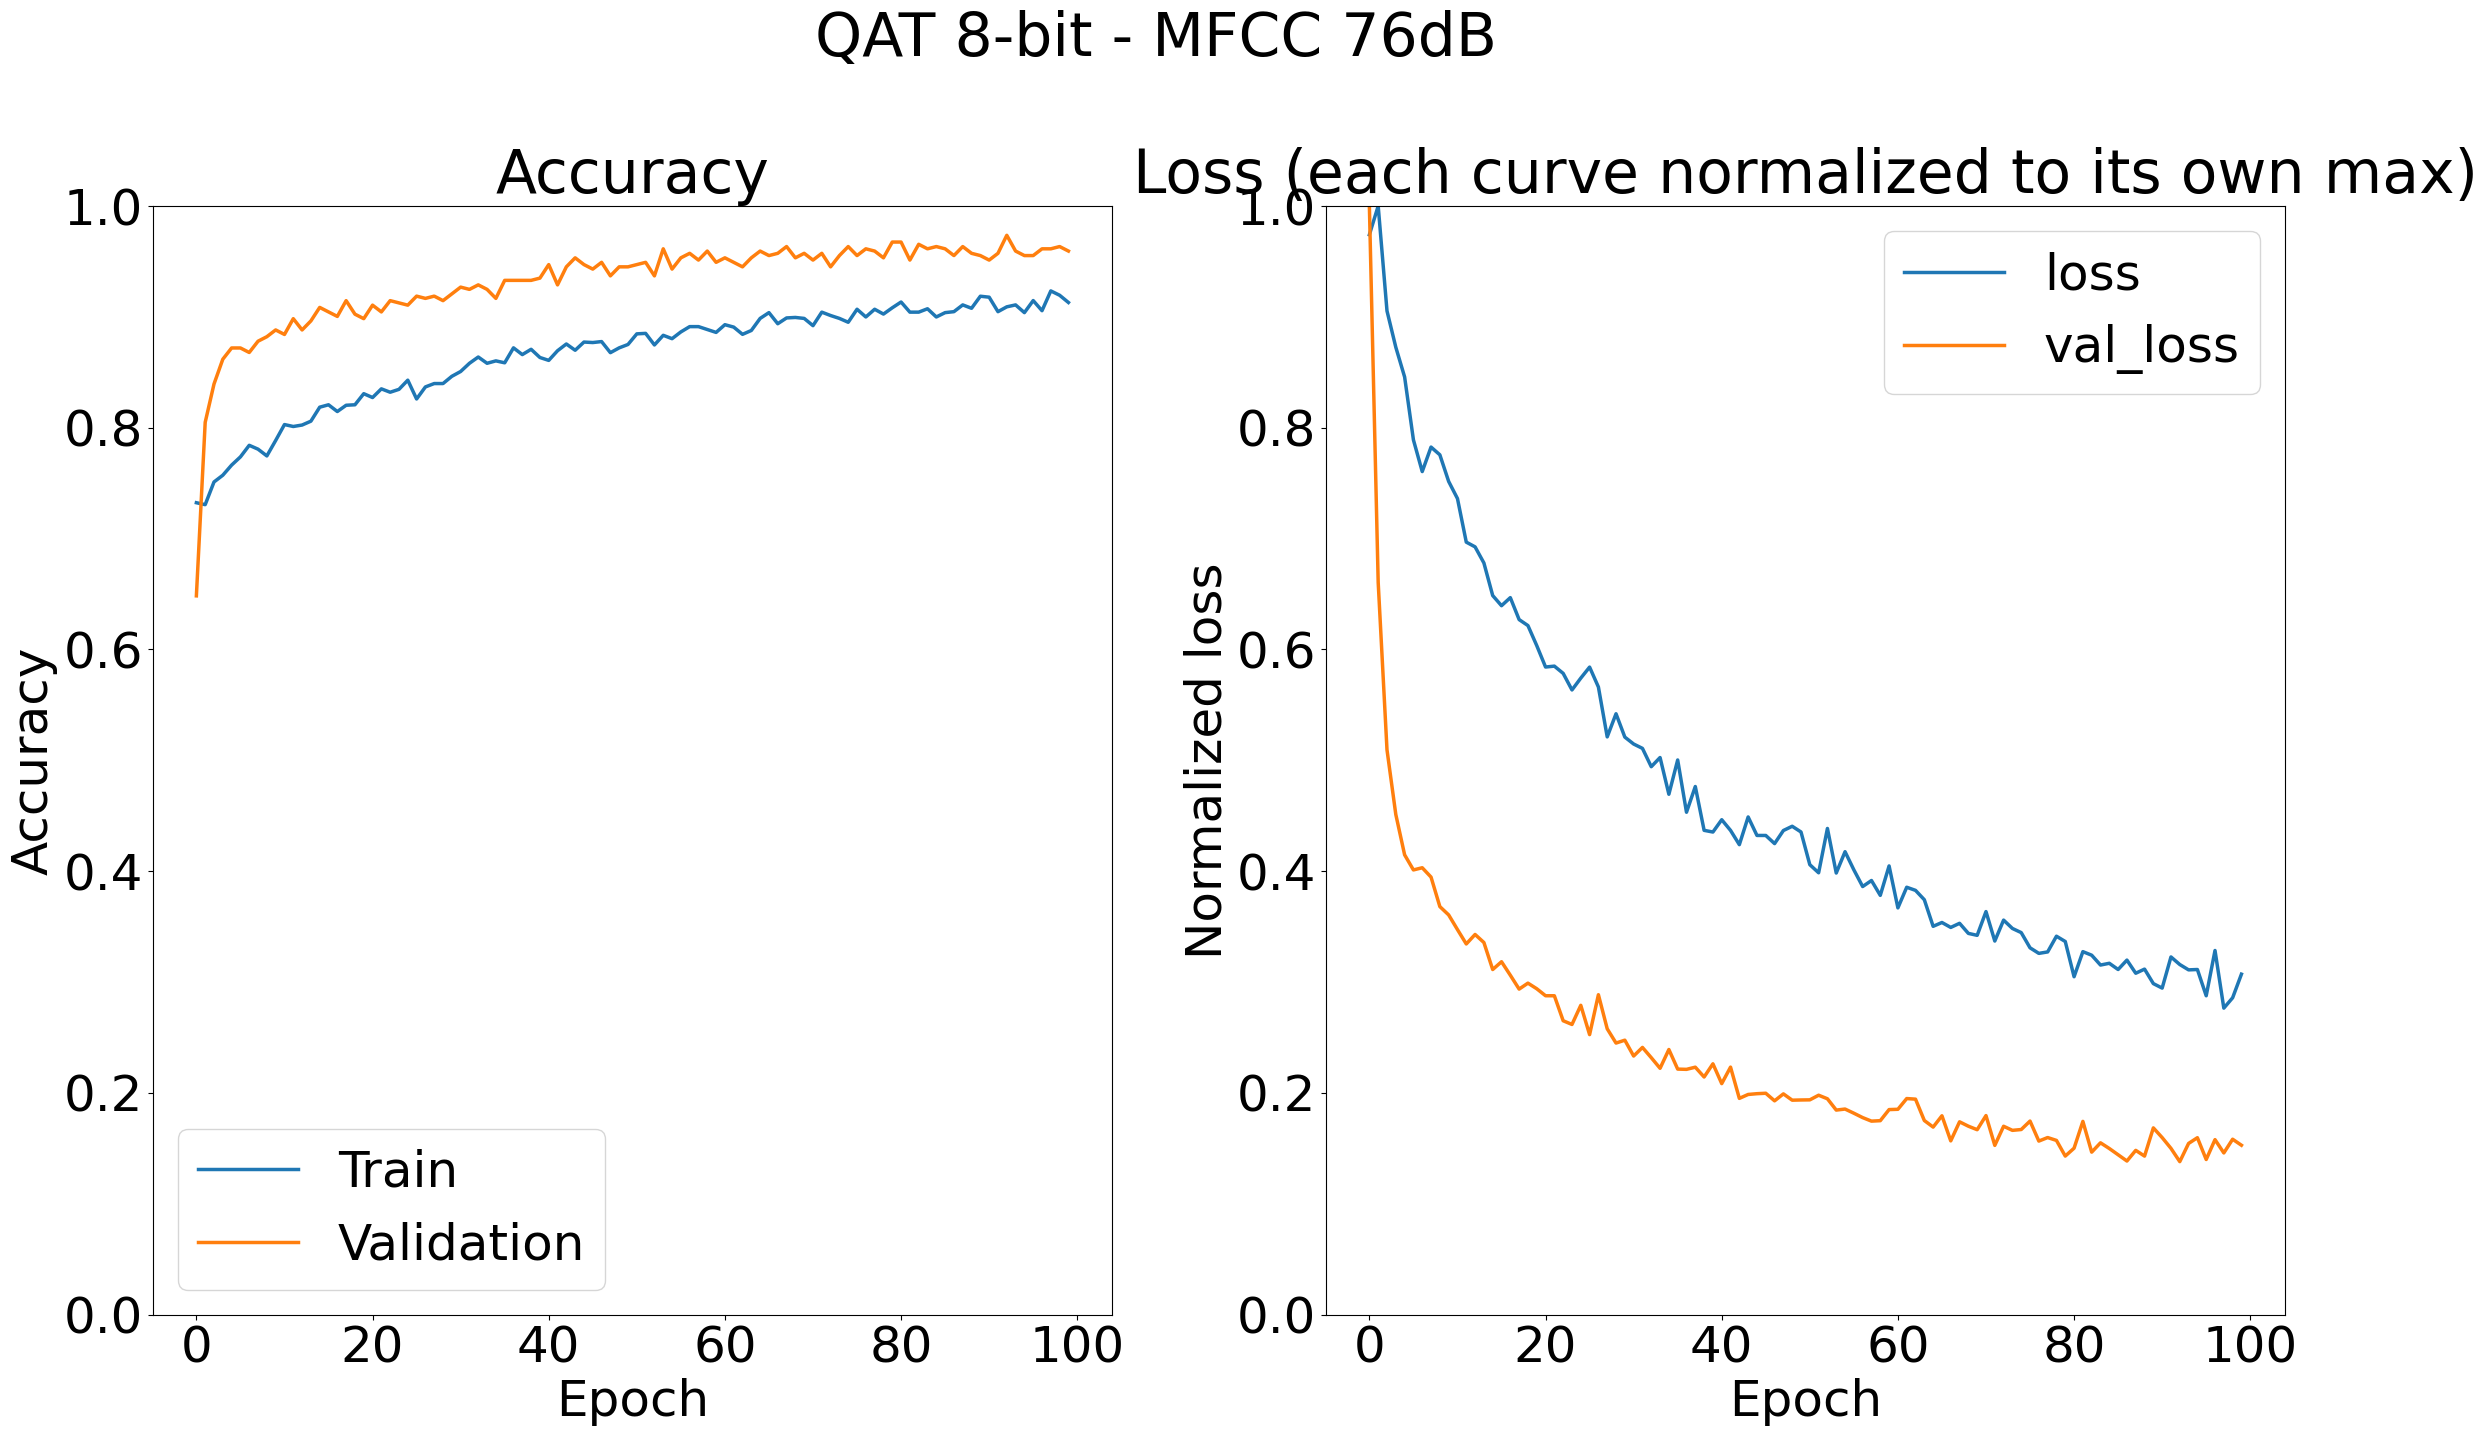


  QAT 4-bit  (integer_bits=2)
Building QAT model and transferring float weights ...
  Transferred weights for 5 layer(s).
Epoch 1/100
72/72 [==============================] - 1s 8ms/step - loss: 2.2868 - accuracy: 0.1327 - val_loss: 2.9916 - val_accuracy: 0.1118
Epoch 2/100
72/72 [==============================] - 0s 6ms/step - loss: 2.2875 - accuracy: 0.1336 - val_loss: 2.5963 - val_accuracy: 0.1118
Epoch 3/100
72/72 [==============================] - 0s 6ms/step - loss: 2.2874 - accuracy: 0.1345 - val_loss: 2.4171 - val_accuracy: 0.1118
Epoch 4/100
72/72 [==============================] - 0s 6ms/step - loss: 2.2879 - accuracy: 0.1332 - val_loss: 2.3379 - val_accuracy: 0.1118
Epoch 5/100
72/72 [==============================] - 0s 6ms/step - loss: 2.2884 - accuracy: 0.1349 - val_loss: 2.3036 - val_accuracy: 0.1118
Epoch 6/100
72/72 [==============================] - 0s 6ms/step - loss: 2.2878 - accuracy: 0.1336 - val_loss: 2.2892 - val_accuracy: 0.1159
Epoch 7/100
72/72 [============

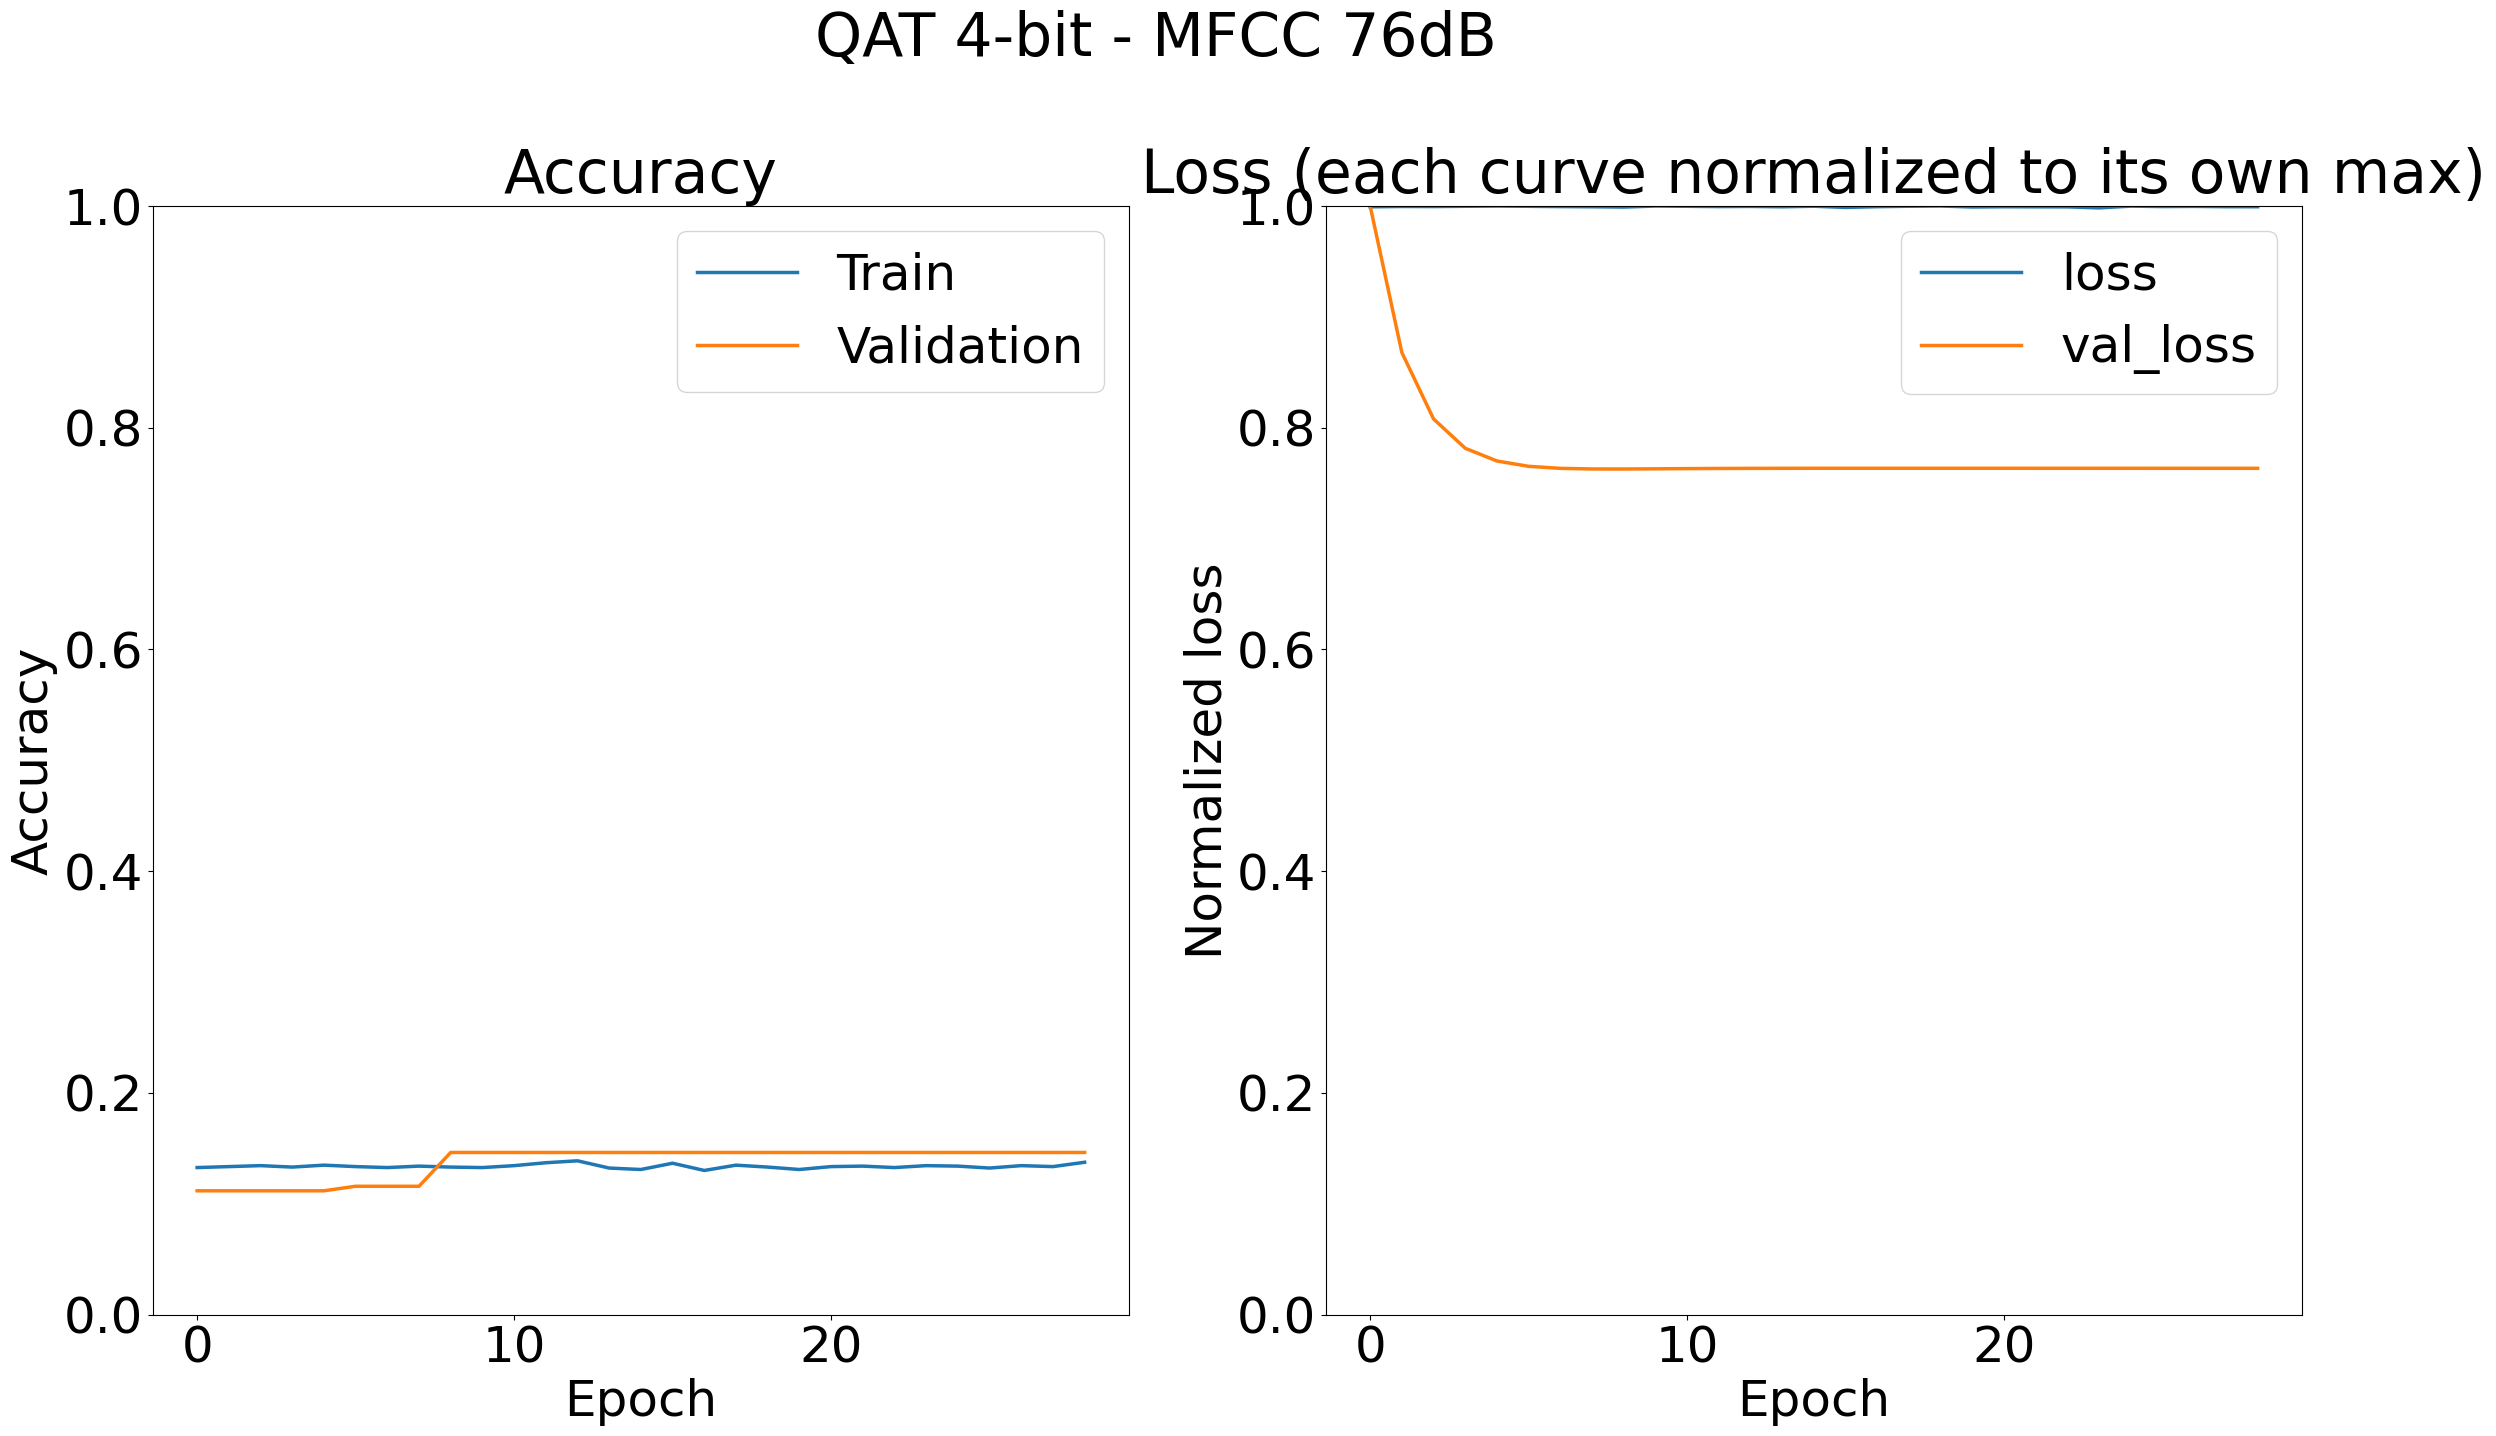

In [10]:

# QAT configs: (total_bits, integer_bits, fine_tune_epochs, learning_rate)
QAT_CONFIGS = [
    (16, 6, 30, 1e-5),
    ( 8, 4, 40, 5e-6),
    ( 4, 2, 60, 1e-6),
]

qat_models   = {}  # bits -> trained QKeras model
qat_results  = {}  # bits -> (loss, accuracy)

for bits, int_bits, ft_epochs, ft_lr in QAT_CONFIGS:
    label     = f'{bits}bit'
    ckpt_dir  = f'./ckpt_FC_QAT_{label}_{TARGET_SNR}'
    best_path = f'{ckpt_dir}/MFCC_QAT_{label}_best.keras'
    hist_path = f'{ckpt_dir}/MFCC_QAT_{label}_history.json'
    os.makedirs(ckpt_dir, exist_ok=True)

    print(f"\n{'='*60}")
    print(f'  QAT {bits}-bit  (integer_bits={int_bits})')
    print(f"{'='*60}")

    if os.path.exists(best_path):
        print(f'  Pre-trained QAT model found: {best_path}')
        print('  Loading.  Delete this file to retrain.')
        model_q = tf.keras.models.load_model(
            best_path, custom_objects=QKERAS_CUSTOM_OBJECTS
        )
        # FIX #7: always recompile with explicit parameters
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
    else:
        print(f"Building QAT model and transferring float weights ...")
        
        model_q = build_qat_model(MFCC_input_shape, NUM_CLASSES, bits, int_bits)
        model_q.compile(
            optimizer=Adam(learning_rate=ft_lr),
            loss='sparse_categorical_crossentropy',
            metrics=['accuracy']
        )
        transfer_float_weights(Model_Float, model_q)

        # FIX #3: fresh callbacks per training session
        cbs = [
            tf.keras.callbacks.ModelCheckpoint(
                filepath=best_path, monitor='val_accuracy',
                save_best_only=True, verbose=1
            ),
            tf.keras.callbacks.EarlyStopping(
                monitor='val_loss', patience=max(10, PATIENCE // 2),
                restore_best_weights=True, verbose=1
            ),
        ]

        hist_q = model_q.fit(
            MFCC_dataset_train_batches,
            epochs=MAX_EPOCHS,
            validation_data=MFCC_dataset_validation_batches,
            callbacks=[early_stopping_callback]
        )
        save_history(hist_q, hist_path)

    if os.path.exists(hist_path):
        plot_training_history(load_history(hist_path),
                              title=f'QAT {bits}-bit - MFCC {TARGET_SNR}')
    

    qat_models[bits] = model_q

## Evaluate All Models

In [13]:
all_results = []

loss, acc = Model_Float.evaluate( MFCC_dataset_validation_batches, verbose=1)
all_results.append({'model': 'Float 32-bit', 'accuracy': acc, 'loss': loss})

for bits in [16, 8, 4]:
    print(f'\n--- QAT {bits}-bit ---')
    loss, acc =  qat_models[bits].evaluate( MFCC_dataset_validation_batches, verbose=1)
    
    all_results.append({'model': f'QAT {bits}-bit', 'accuracy': acc, 'loss': loss})

print('\n' + '='*50)
print(f'{"Model":<18} {"Accuracy":>10} {"Loss":>10}')
print('='*50)
for r in all_results:
    print(f"{r['model']:<18} {r['accuracy']:>10.4f} {r['loss']:>10.4f}")
print('='*50)

 1/16 [>.............................] - ETA: 0s - loss: 0.1382 - accuracy: 0.9375

16/16 [==============================] - 0s 1ms/step - loss: 0.1122 - accuracy: 0.9654

--- QAT 16-bit ---
16/16 [==============================] - 0s 3ms/step - loss: 0.0905 - accuracy: 0.9675

--- QAT 8-bit ---
16/16 [==============================] - 0s 3ms/step - loss: 0.1525 - accuracy: 0.9593

--- QAT 4-bit ---
16/16 [==============================] - 0s 2ms/step - loss: 2.2820 - accuracy: 0.1463

Model                Accuracy       Loss
Float 32-bit           0.9654     0.1122
QAT 16-bit             0.9675     0.0905
QAT 8-bit              0.9593     0.1525
QAT 4-bit              0.1463     2.2820


## hls4ml Synthesis – Vitis HLS → Bitstream-Ready IP

Each of the four models is converted to a Vitis HLS project and
synthesized for **`xck26-sfvc784-2LV-c`** at **200 MHz (5 ns)**.

The exported IP-XACT package can be added to a Vivado block design
to generate the final bitstream.


In [ ]:
def get_hls_config(keras_model, is_qat, bits=32):
    config = hls4ml.utils.config_from_keras_model(
        keras_model, granularity='name'
    )
    config['Model']['Strategy']    = 'Resource'  # minimize LUT / DSP
    config['Model']['ReuseFactor'] = 1

    if not is_qat:
        # Float model: use ap_fixed<32,12> for highest baseline accuracy
        config['Model']['Precision'] = 'ap_fixed<32,12>'
    # For QAT models hls4ml reads precision from QKeras quantizers automatically

    # The Flatten -> Dense(128) layer has 22 400 inputs.
    # xck26 has ~128 DSP48s. Minimum RF = ceil(22400/128) = 175.
    # Using 256 (next power-of-two) for alignment.
    LARGE_RF = 256
    for lname in config['LayerName']:
        if 'dense1' in lname:
            config['LayerName'][lname]['ReuseFactor'] = LARGE_RF
            config['LayerName'][lname]['Strategy']    = 'Resource'
    return config


def synthesize_model(keras_model, output_dir, label, is_qat=False, bits=32):
    print(f"\n{'─'*60}")
    print(f'  Synthesizing : {label}')
    print(f'  Output dir   : {output_dir}')
    print(f"{'─'*60}")

    config    = get_hls_config(keras_model, is_qat=is_qat, bits=bits)
    hls_model = hls4ml.converters.convert_from_keras_model(
        keras_model,
        hls_config   = config,
        output_dir   = output_dir,
        backend      = 'Vitis',
        part         = FPGA_PART,
        clock_period = CLOCK_PERIOD   # 5 ns -> 200 MHz
    )

    # C simulation checks functional correctness before RTL synthesis
    hls_model.compile()

    # Full synthesis + IP-XACT export (Vivado-importable bitstream-ready IP)
    hls_model.build(csim=False, synth=True, cosim=False, export=True)

    print(f'  Done: {label}')
    return hls_model


def parse_synth_report(output_dir, label):
    rpt = {'model': label}
    candidates = [
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'myproject_csynth.rpt'),
        os.path.join(output_dir, 'myproject_prj', 'solution1',
                     'syn', 'report', 'csynth.rpt'),
    ]
    rpt_path = next((p for p in candidates if os.path.exists(p)), None)
    if rpt_path is None:
        print(f'  Warning: report not found for {label}')
        return rpt
    content = open(rpt_path).read()

    # Latency
    m = re.search(
        r'Latency.*?Min.*?:(\s*)(\d+).*?Max.*?:(\s*)(\d+)',
        content, re.DOTALL | re.IGNORECASE
    )
    if m:
        rpt['lat_min_cyc'] = int(m.group(2))
        rpt['lat_max_cyc'] = int(m.group(4))
        rpt['lat_min_us']  = round(int(m.group(2)) * CLOCK_PERIOD / 1000, 3)
        rpt['lat_max_us']  = round(int(m.group(4)) * CLOCK_PERIOD / 1000, 3)

    # Resources
    for res in ['LUT', 'FF', 'DSP', 'BRAM_18K']:
        m = re.search(
            rf'\|?\s*{res}\s*\|?\s*(\d+)\s*\|?\s*(\d+)\s*\|?\s*([\d.]+)\s*%',
            content
        )
        if m:
            rpt[f'{res}_used'] = int(m.group(1))
            rpt[f'{res}_avail']= int(m.group(2))
            rpt[f'{res}_pct']  = float(m.group(3))
    return rpt

## Run Synthesis

In [ ]:
os.makedirs(HLS_BASE_DIR, exist_ok=True)

synth_targets = [
    # (model,           subdir,      label,         is_qat, bits)
    (model_float,       'float_32',  'Float 32-bit', False, 32),
    (qat_models[16],    'qat_16bit', 'QAT 16-bit',   True,  16),
    (qat_models[8],     'qat_8bit',  'QAT 8-bit',    True,   8),
    (qat_models[4],     'qat_4bit',  'QAT 4-bit',    True,   4),
]

hls_handles   = {}
synth_reports = []

for model, subdir, label, is_qat, bits in synth_targets:
    out_dir = os.path.join(HLS_BASE_DIR, subdir)
    hm = synthesize_model(model, out_dir, label, is_qat=is_qat, bits=bits)
    hls_handles[label]   = hm
    synth_reports.append(parse_synth_report(out_dir, label))

## Results Summary

In [ ]:
# ── Accuracy / loss ──────────────────────────────────────────────────────
print('='*55)
print(f'{"Model":<18} {"Accuracy":>10} {"Loss":>10}')
print('='*55)
for r in all_results:
    print(f"{r['model']:<18} {r['accuracy']:>10.4f} {r['loss']:>10.4f}")
print('='*55)

# ── Synthesis resources & latency ────────────────────────────────────────
print('\n')
df_rpt = pd.DataFrame(synth_reports)
want   = ['model',
          'lat_min_us', 'lat_max_us',
          'LUT_used', 'LUT_pct',
          'FF_used',  'FF_pct',
          'DSP_used', 'DSP_pct',
          'BRAM_18K_used', 'BRAM_18K_pct']
show   = [c for c in want if c in df_rpt.columns]
print(df_rpt[show].to_string(index=False))

print(f'\nAll models targeted at {FPGA_PART} @ {1000//CLOCK_PERIOD} MHz')
print('IP-XACT packages are in <output_dir>/myproject_prj/solution1/impl/ip/')
print('Import them into a Vivado block design and run Generate Bitstream.')